In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
# Define results directory and load data
# results_dir = os.path.expanduser('~/OneDrive - The University of Sydney (Staff)/Shared/Projects/01_PhD/03_Physics_Informed/05_groundwater/groundwater_main/results/')
results_dir = '/scratch/yl75/ak4177/results/groundwater/GINO_predictions/'

# results_dir = os.path.join(results_dir, 'updated_lowres', 'resolution_0.167/gino_predictions_20260327_211533')
# results_dir = os.path.join(results_dir, 'updated_lowres', 'resolution_1.0/gino_predictions_20260327_092303')

# Static
# results_dir = os.path.expanduser('~/Projects/groundwater/results/gw_sciml/static_sampling/resolution_0.30/gino_predictions_20260529_095651')
# results_dir = os.path.expanduser('~/Projects/groundwater/results/gw_sciml/static_sampling/resolution_1.0/gino_predictions_20260529_095931')

# results_dir = os.path.join(results_dir, 'static_sampling', 'resolution_0.40/gino_predictions_20260706_105346')
results_dir = os.path.join(results_dir, 'static_sampling', 'resolution_1.0/gino_predictions_20260713_095614')

# Load validation predictions and training coordinates
val_preds = np.load(os.path.join(results_dir, 'val_predictions.npy'))
coords = pickle.load(open(os.path.join(results_dir, 'train_coords.pkl'), 'rb'))[0]

# Apply inverse coordinate transformation
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])

# denormalize coordinates
denorm_coords = coords * coord_std + coord_mean

In [3]:
# Load Targets
val_targets = np.load(os.path.join(results_dir, 'val_targets.npy'))

# Extract mass concentration for the last time step
# Reshape predictions and targets to (N_nodes, T, N_vars)
if len(val_preds.shape) == 4:
    preds = np.squeeze(val_preds, axis=2).transpose(1, 0, 2)
    targets = np.squeeze(val_targets, axis=2).transpose(1, 0, 2)
else:
    preds = val_preds
    targets = val_targets

# Extract mass concentration time-series
mass_conc_preds = preds[..., 0]/1000 # Convert from g/m3 to kg/m3
mass_conc_targets = targets[..., 0]/1000 # Convert from g/m3 to kg/m3

# Extract hydraulic head time-series
head_preds = preds[..., 1]
head_targets = targets[..., 1]

print(f"Data shape for mass concentration (preds): {mass_conc_preds.shape}")
print(f"Data shape for mass concentration (targets): {mass_conc_targets.shape}")
print(f"Data shape for hydraulic head (preds): {head_preds.shape}")
print(f"Data shape for hydraulic head (targets): {head_targets.shape}")

Data shape for mass concentration (preds): (61360, 568)
Data shape for mass concentration (targets): (61360, 568)
Data shape for hydraulic head (preds): (61360, 568)
Data shape for hydraulic head (targets): (61360, 568)


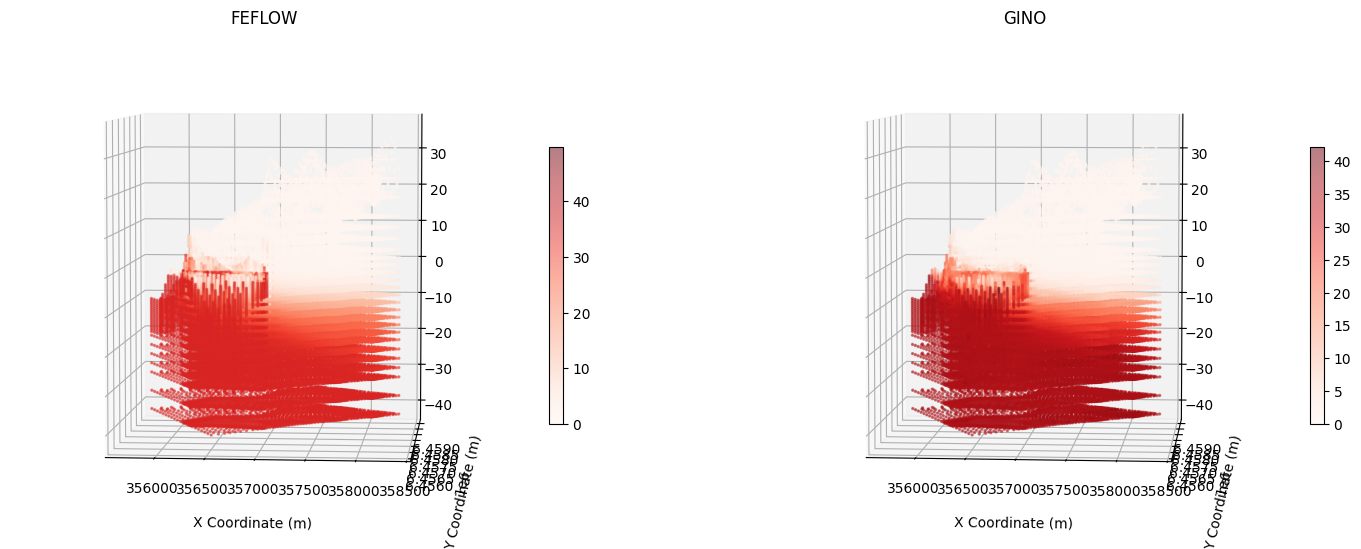

In [4]:
# Plot final time step error for mass concentration and hydraulic head in 3D scatter plot
fig, axs = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': '3d'})

# Plotting
sc = axs[0].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
                    c=mass_conc_targets[:, -1], cmap='Reds', alpha=0.5, s=2)
axs[0].set_title('FEFLOW')
axs[0].set_xlabel('X Coordinate (m)')
axs[0].set_ylabel('Y Coordinate (m)')
plt.colorbar(sc, ax=axs[0], shrink=0.3)


# Plot Signed Error for mass concentration
sc1 = axs[1].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
                    c=np.clip(mass_conc_preds[:, -1], 0, None), cmap='Reds', alpha=0.5, s=2)
axs[1].set_title('GINO')
axs[1].set_xlabel('X Coordinate (m)')
axs[1].set_ylabel('Y Coordinate (m)')
plt.colorbar(sc1, ax=axs[1], shrink=0.3)


for ax in axs:
    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))

    # View Angle
    ax.view_init(elev=5, azim=275)

    # Padding
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

In [5]:
# # Plot final time step error for mass concentration and hydraulic head in 3D scatter plot
# fig, ax = plt.subplots(1, 1, figsize=(18, 12), subplot_kw={'projection': '3d'})

# # Plot Signed Error for mass concentration
# clipped_preds = np.clip(mass_conc_preds[:, -1], 0, 35)
# clipped_targets = np.clip(mass_conc_targets[:, -1], 0, 35)
# err = clipped_targets - clipped_preds

# # Mask by z
# z_mask = [True] * len(denorm_coords) #(denorm_coords[:, -1] > -25) & (denorm_coords[:, -1] < -15)
# denorm_coords_masked = denorm_coords[z_mask]
# err_masked = err[z_mask]
# clipped_preds_masked = clipped_preds[z_mask]
# clipped_targets_masked = clipped_targets[z_mask]

# selected_nodes = (clipped_preds_masked < 5) & (clipped_targets_masked > 15)
# sc1 = ax.scatter(denorm_coords_masked[:, 0], denorm_coords_masked[:, 1], denorm_coords_masked[:, 2], 
#                     c=err_masked, cmap='Reds', alpha=0.5, s=2)
# sc2 = ax.scatter(denorm_coords_masked[selected_nodes, 0], denorm_coords_masked[selected_nodes, 1], denorm_coords_masked[selected_nodes, 2], 
#                     c='black', alpha=1.0, s=5)
# ax.set_title(f'Error: No-anomaly: {err_masked[~selected_nodes].mean():.2f} Anomaly: {err_masked[selected_nodes].mean():.2f} Len: {sum(selected_nodes)}')
# ax.set_xlabel('X Coordinate (m)')
# ax.set_ylabel('Y Coordinate (m)')
# plt.colorbar(sc1, ax=ax, shrink=0.3)


# # Aspect Ratio
# ax.set_box_aspect((1, 1, 1.1))

# # View Angle
# ax.view_init(elev=20, azim=5)

# # Padding
# ax.xaxis.labelpad = 10
# ax.yaxis.labelpad = 10
# ax.zaxis.labelpad = 5

In [6]:
def np_l2_norm_error(preds, targets):
    return np.linalg.norm(preds - targets, ord=2, axis=1) / np.linalg.norm(targets, axis=1, ord=2)

def r2_score(preds, targets):
    ss_res = np.sum((targets - preds) ** 2, axis=1)
    ss_tot = np.sum((targets - np.mean(targets, axis=1, keepdims=True)) ** 2, axis=1)
    print(ss_tot)
    return 1 - (ss_res / ss_tot)

def signed_error(preds, targets):
    return np.mean(preds - targets, axis=1)

def mae(preds, targets):
    return np.mean(np.abs(preds - targets), axis=1)

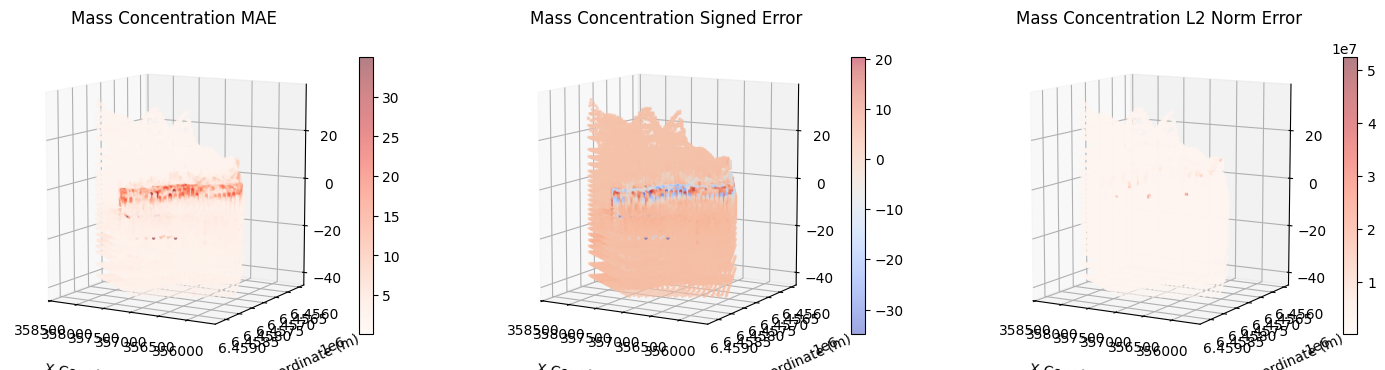

In [7]:
# Plot final time step error for mass concentration and hydraulic head in 3D scatter plot
fig, axs = plt.subplots(1, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})

# MAE for mass concentration
mae_mass_conc = mae(mass_conc_preds, mass_conc_targets)

# L2 norm error for mass concentration
l2_mass_conc = np_l2_norm_error(mass_conc_preds, mass_conc_targets)


# Signed Error for mass concentration
signed_err_mass_conc = signed_error(mass_conc_preds, mass_conc_targets)

# Plotting
sc = axs[0].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
                    c=mae_mass_conc, cmap='Reds', alpha=0.5, s=2)
axs[0].set_title('Mass Concentration MAE')
axs[0].set_xlabel('X Coordinate (m)')
axs[0].set_ylabel('Y Coordinate (m)')
plt.colorbar(sc, ax=axs[0], shrink=0.3)


# Plot Signed Error for mass concentration
sc1 = axs[1].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
                    c=signed_err_mass_conc, cmap='coolwarm', alpha=0.5, s=2)
axs[1].set_title('Mass Concentration Signed Error')
axs[1].set_xlabel('X Coordinate (m)')
axs[1].set_ylabel('Y Coordinate (m)')
plt.colorbar(sc1, ax=axs[1], shrink=0.3)


# Plot L2 norm error for mass concentration
sc2 = axs[2].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
                    c=l2_mass_conc, cmap='Reds', alpha=0.5, s=2)
axs[2].set_title('Mass Concentration L2 Norm Error')
axs[2].set_xlabel('X Coordinate (m)')
axs[2].set_ylabel('Y Coordinate (m)')
plt.colorbar(sc2, ax=axs[2], shrink=0.3)


# # Mass Concentration plot Mean Values
mean_mass_conc = np.mean(mass_conc_targets, axis=1)
# sc2 = axs[1].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
#                     c=mean_mass_conc, cmap='viridis', alpha=0.5, s=2)
# axs[1].set_title('Mass Concentration Mean Values')
# axs[1].set_xlabel('X Coordinate (m)')
# axs[1].set_ylabel('Y Coordinate (m)')
# plt.colorbar(sc2, ax=axs[1], shrink=0.3)

# # Mass Concentration plot Standard Deviation Values
std_mass_conc = np.std(mass_conc_targets, axis=1)
# sc3 = axs[2].scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], 
#                     c=std_mass_conc, cmap='plasma', alpha=0.5, s=2)
# axs[2].set_title('Mass Concentration Standard Deviation')
# axs[2].set_xlabel('X Coordinate (m)')
# axs[2].set_ylabel('Y Coordinate (m)')
# plt.colorbar(sc3, ax=axs[2], shrink=0.3)

for ax in axs:
    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))

    # View Angle
    ax.view_init(elev=10, azim=120)

    # Padding
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5



/jobfs/173690325.gadi-pbs/ipykernel_3183753/3524701000.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(signed_err_mass_conc[filter_mask], denorm_coords[filter_mask, 2], alpha=0.6, color='black', s=1, cmap='vanimo')


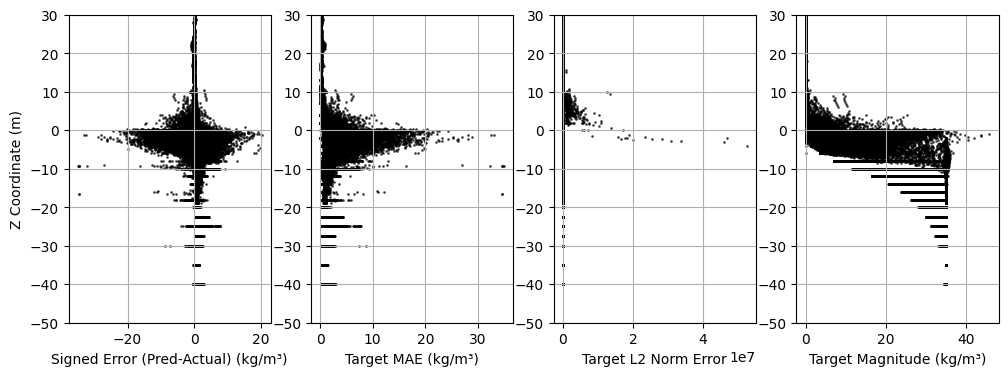

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

filter_mask = mae_mass_conc > 0

# Plot error vs z coordinate
ax[0].scatter(signed_err_mass_conc[filter_mask], denorm_coords[filter_mask, 2], alpha=0.6, color='black', s=1, cmap='vanimo')
ax[0].set_ylabel('Z Coordinate (m)')
ax[0].set_xlabel('Signed Error (Pred-Actual) (kg/m³)')
ax[0].set_ylim(-50, 30)
# plt.colorbar(ax[0].collections[0], ax=ax[0], shrink=1.0, aspect=50)
ax[0].grid()

# Plot mae vs z coordinate
sc2 = ax[1].scatter(mae_mass_conc[filter_mask], denorm_coords[filter_mask, 2], alpha=0.6, s=1, color='black')#, cmap='vanimo')
ax[1].set_xlabel('Target MAE (kg/m³)')
# plt.colorbar(sc2, ax=ax[1], shrink=1.0, aspect=50)
ax[1].set_ylim(-50, 30)
ax[1].grid()

# Plot L2 norm error vs z coordinate
sc2 = ax[2].scatter(l2_mass_conc[filter_mask], denorm_coords[filter_mask, 2], alpha=0.6, s=1, color='black')#, cmap='vanimo')
ax[2].set_xlabel('Target L2 Norm Error')
# plt.colorbar(sc2, ax=ax[2], shrink=1.0, aspect=50)
ax[2].set_ylim(-50, 30)
ax[2].grid()

# Plot magnitude vs z coordinate
sc3 = ax[3].scatter(mean_mass_conc[filter_mask], denorm_coords[filter_mask, 2], alpha=0.6, s=1, color='black')#, cmap='vanimo')
ax[3].set_xlabel('Target Magnitude (kg/m³)')
# plt.colorbar(sc3, ax=ax[3], shrink=1.0, aspect=50)
ax[3].set_ylim(-50, 30)
ax[3].grid()


# # Plot standard deviation vs z coordinate
# sc3 = ax[2].scatter(np.square(std_mass_conc[filter_mask]), denorm_coords[filter_mask, 2], alpha=0.6, s=1, color='black', cmap='vanimo')
# ax[2].set_xlabel('Target Temporal Variance (kg/m³)')
# # plt.colorbar(sc3, ax=ax[2], shrink=1.0, aspect=50)
# ax[2].set_ylim(-50, 30)
# ax[2].grid()


plt.show()

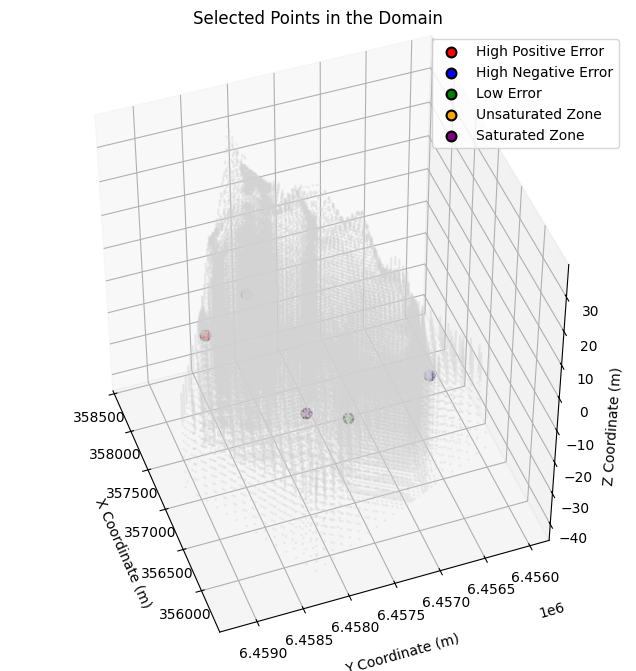

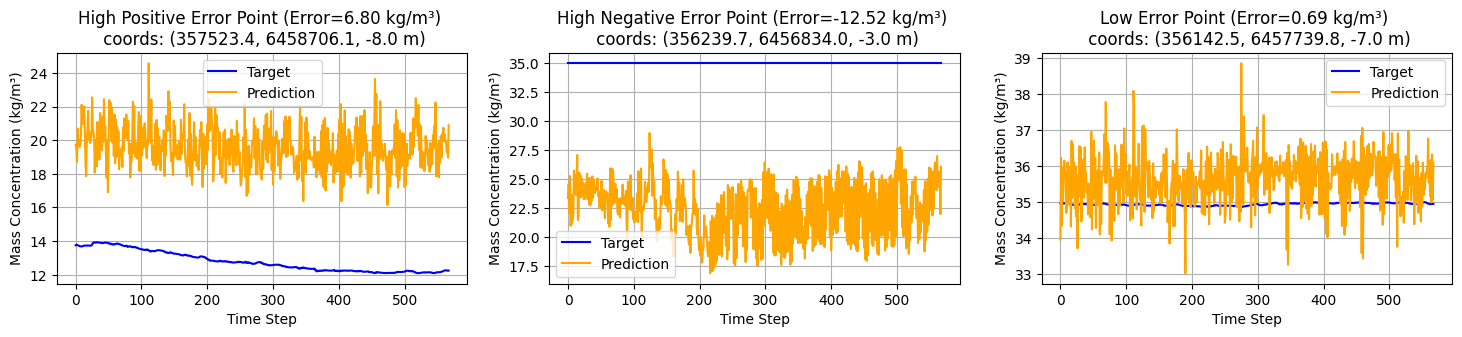

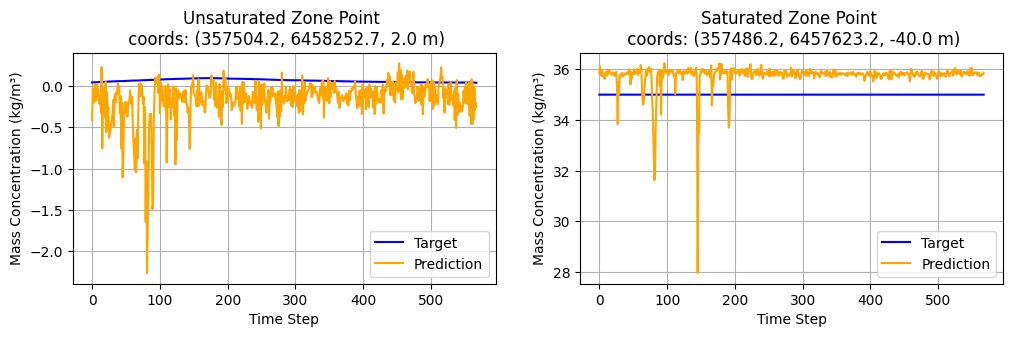

In [9]:
# Transition zone points
low_error_mask = mae_mass_conc < 1
low_z_mask = (denorm_coords[:, 2] > -10) & (denorm_coords[:, 2] < 2)

# Filter a point with error > 6 kg/m3 and plot its time-series
high_pos_error_mask = signed_err_mass_conc > 6
high_neg_error_mask = signed_err_mass_conc < -6

# Saturated and Unsaturated Zones
unsaturated_mask = denorm_coords[:, 2] > 2
saturated_mask = (denorm_coords[:, 2] < -15) & (denorm_coords[:, 0] < 357500)

# Randomly select one point from each category (high positive error, high negative error, low error) within the transition zone
high_pos_error_idx = np.random.choice(np.where(high_pos_error_mask & low_z_mask)[0], size=1, replace=False)[0]
high_neg_error_idx = np.random.choice(np.where(high_neg_error_mask & low_z_mask)[0], size=1, replace=False)[0]
low_error_idx = np.random.choice(np.where(low_error_mask & low_z_mask)[0], size=1, replace=False)[0]


# Randomly select one point from saturated and unsaturated zones
unsaturated_idx = np.random.choice(np.where(unsaturated_mask)[0], size=1, replace=False)[0]
saturated_idx = np.random.choice(np.where(saturated_mask)[0], size=1, replace=False)[0]


# 3D plot of the selected points highlighted in the domain
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
# Reduced alpha of domain points for better contrast
ax.scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], c='lightgray', alpha=0.24, s=1)

# Marker settings for better visibility
marker_kwargs = {'s': 50, 'alpha': 1, 'edgecolors': 'black', 'linewidths': 1.5, 'zorder': 10}

ax.scatter(denorm_coords[high_pos_error_idx, 0], denorm_coords[high_pos_error_idx, 1], denorm_coords[high_pos_error_idx, 2], c='red', label='High Positive Error', **marker_kwargs)
ax.scatter(denorm_coords[high_neg_error_idx, 0], denorm_coords[high_neg_error_idx, 1], denorm_coords[high_neg_error_idx, 2], c='blue', label='High Negative Error', **marker_kwargs)
ax.scatter(denorm_coords[low_error_idx, 0], denorm_coords[low_error_idx, 1], denorm_coords[low_error_idx, 2], c='green', label='Low Error', **marker_kwargs)
ax.scatter(denorm_coords[unsaturated_idx, 0], denorm_coords[unsaturated_idx, 1], denorm_coords[unsaturated_idx, 2], c='orange', label='Unsaturated Zone', **marker_kwargs)
ax.scatter(denorm_coords[saturated_idx, 0], denorm_coords[saturated_idx, 1], denorm_coords[saturated_idx, 2], c='purple', label='Saturated Zone', **marker_kwargs)
ax.set_title('Selected Points in the Domain')
ax.set_xlabel('X Coordinate (m)')
ax.set_ylabel('Y Coordinate (m)')
ax.set_zlabel('Z Coordinate (m)')
ax.legend()

# Aspect Ratio
ax.set_box_aspect((1, 1, 1.1))

# View Angle
ax.view_init(elev=45, azim=160)

# Padding
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 5

plt.show()


fig, ax = plt.subplots(1, 3, figsize=(18, 3))

ax[0].plot(mass_conc_targets[high_pos_error_idx], label='Target', color='blue')
ax[0].plot(mass_conc_preds[high_pos_error_idx], label='Prediction', color='orange')
ax[0].set_title(f'High Positive Error Point (Error={signed_err_mass_conc[high_pos_error_idx]:.2f} kg/m³) \n coords: ({denorm_coords[high_pos_error_idx, 0]:.1f}, {denorm_coords[high_pos_error_idx, 1]:.1f}, {denorm_coords[high_pos_error_idx, 2]:.1f} m)')
ax[0].set_xlabel('Time Step')
ax[0].set_ylabel('Mass Concentration (kg/m³)')
ax[0].legend()
ax[0].grid()


ax[1].plot(mass_conc_targets[high_neg_error_idx], label='Target', color='blue')
ax[1].plot(mass_conc_preds[high_neg_error_idx], label='Prediction', color='orange')
ax[1].set_title(f'High Negative Error Point (Error={signed_err_mass_conc[high_neg_error_idx]:.2f} kg/m³) \n coords: ({denorm_coords[high_neg_error_idx, 0]:.1f}, {denorm_coords[high_neg_error_idx, 1]:.1f}, {denorm_coords[high_neg_error_idx, 2]:.1f} m)')
ax[1].set_xlabel('Time Step')
ax[1].set_ylabel('Mass Concentration (kg/m³)')
ax[1].legend()
ax[1].grid()

ax[2].plot(mass_conc_targets[low_error_idx], label='Target', color='blue')
ax[2].plot(mass_conc_preds[low_error_idx], label='Prediction', color='orange')
ax[2].set_title(f'Low Error Point (Error={signed_err_mass_conc[low_error_idx]:.2f} kg/m³) \n coords: ({denorm_coords[low_error_idx, 0]:.1f}, {denorm_coords[low_error_idx, 1]:.1f}, {denorm_coords[low_error_idx, 2]:.1f} m)')

ax[2].set_xlabel('Time Step')
ax[2].set_ylabel('Mass Concentration (kg/m³)')
ax[2].legend()
ax[2].grid()

plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(mass_conc_targets[unsaturated_idx], label='Target', color='blue')
ax[0].plot(mass_conc_preds[unsaturated_idx], label='Prediction', color='orange')
ax[0].set_title(f'Unsaturated Zone Point \n coords: ({denorm_coords[unsaturated_idx, 0]:.1f}, {denorm_coords[unsaturated_idx, 1]:.1f}, {denorm_coords[unsaturated_idx, 2]:.1f} m)')
ax[0].set_xlabel('Time Step')
ax[0].set_ylabel('Mass Concentration (kg/m³)')
ax[0].legend()
ax[0].grid()

ax[1].plot(mass_conc_targets[saturated_idx], label='Target', color='blue')
ax[1].plot(mass_conc_preds[saturated_idx], label='Prediction', color='orange')
ax[1].set_title(f'Saturated Zone Point \n coords: ({denorm_coords[saturated_idx, 0]:.1f}, {denorm_coords[saturated_idx, 1]:.1f}, {denorm_coords[saturated_idx, 2]:.1f} m)')
ax[1].set_xlabel('Time Step')
ax[1].set_ylabel('Mass Concentration (kg/m³)')
ax[1].legend()
ax[1].grid()

plt.show()